In [1]:
import os
import copy
import math
import subprocess
import sys

import numpy as np
import scipy.signal as signal
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

# Auto-install missing lightweight deps in notebook environments.
try:
    import wfdb
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'wfdb'])
    import wfdb

try:
    from tqdm.auto import tqdm
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tqdm'])
    from tqdm.auto import tqdm


/home/durgesh/.conda/envs/tf210/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def bandpass_filter(signal_data, fs=100, lowcut=0.5, highcut=40, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = signal.butter(order, [low, high], btype='band')
    return signal.filtfilt(b, a, signal_data)

def notch_filter(signal_data, fs=100, freq=50.0, Q=30.0):
    nyq = 0.5 * fs
    w0 = freq / nyq
    b, a = signal.iirnotch(w0, Q)
    return signal.filtfilt(b, a, signal_data)

def preprocess_signal(sig, fs=100):
    sig = np.asarray(sig, dtype=np.float32)
    sig = np.nan_to_num(sig, nan=0.0, posinf=0.0, neginf=0.0)

    sig = bandpass_filter(sig, fs)
    sig = notch_filter(sig, fs)

    sig = np.nan_to_num(sig, nan=0.0, posinf=0.0, neginf=0.0)
    std = np.std(sig)
    if std < 1e-8:
        return np.zeros_like(sig, dtype=np.float32)

    sig = (sig - np.mean(sig)) / (std + 1e-8)
    return sig.astype(np.float32)


In [3]:
def segment_signal(signal_data, annotations, fs=100):
    segments = []
    labels = []
    segment_length = fs * 60

    for i, label in enumerate(annotations):
        start = i * segment_length
        end = start + segment_length

        if end <= len(signal_data):
            seg = signal_data[start:end]
            if not np.isfinite(seg).all():
                continue
            segments.append(seg)
            labels.append(1 if label == 'A' else 0)

    return np.array(segments, dtype=np.float32), np.array(labels, dtype=np.int64)


In [4]:
def load_apnea_dataset(data_path):
    X_all = []
    y_all = []
    skipped = []

    # use records that have apnea annotations
    records = sorted(set(f.split('.')[0] for f in os.listdir(data_path) if f.endswith('.apn')))

    for rec in tqdm(records, desc='Loading records', unit='record'):
        try:
            record = wfdb.rdrecord(os.path.join(data_path, rec))
            annotation = wfdb.rdann(os.path.join(data_path, rec), 'apn')

            signal_data = record.p_signal[:, 0]
            signal_data = preprocess_signal(signal_data, fs=int(record.fs))

            segments, labels = segment_signal(signal_data, annotation.symbol, fs=int(record.fs))
            if len(segments) == 0:
                skipped.append((rec, 'no valid segments'))
                continue

            X_all.append(segments)
            y_all.append(labels)

        except Exception as e:
            skipped.append((rec, str(e)))

    if not X_all:
        raise ValueError('No valid records were loaded.')

    X_all = np.concatenate(X_all, axis=0).astype(np.float32)
    y_all = np.concatenate(y_all, axis=0).astype(np.int64)

    finite_ratio = float(np.isfinite(X_all).mean())
    class_counts = np.bincount(y_all, minlength=2)
    print(f"Total segments: {len(X_all)} | finite_ratio={finite_ratio:.6f}")
    print(f"Class counts -> Normal(0): {class_counts[0]}, Apnea(1): {class_counts[1]}")
    if skipped:
        print(f"Skipped records: {len(skipped)}")

    return X_all, y_all


In [5]:
data_path = "dataset/1.0.0"

X, y = load_apnea_dataset(data_path)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")
train_counts = np.bincount(y_train, minlength=2)
test_counts = np.bincount(y_test, minlength=2)
print(f"Train class counts -> 0: {train_counts[0]}, 1: {train_counts[1]}")
print(f"Test class counts  -> 0: {test_counts[0]}, 1: {test_counts[1]}")


Loading records: 100%|██████████| 86/86 [00:11<00:00,  7.51record/s]


Total segments: 38222 | finite_ratio=1.000000
Class counts -> Normal(0): 23555, Apnea(1): 14667
Skipped records: 8
Train samples: 30577, Test samples: 7645
Train class counts -> 0: 18844, 1: 11733
Test class counts  -> 0: 4711, 1: 2934


In [6]:
class ApneaDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(ApneaDataset(X_train, y_train), batch_size=32, num_workers=4, shuffle=True, pin_memory=True)
test_loader = DataLoader(ApneaDataset(X_test, y_test), batch_size=32, num_workers=4, pin_memory=True)


In [7]:
# Vanilla transformer attention block copied from exp14

class SparseAttentionBlock(nn.Module):
    """
    Vanilla transformer attention block for fetal ECG.
    Uses standard MultiheadAttention from PyTorch.
    Handles projections and reshaping to fit into the U-Net architecture.
    """
    def __init__(self, in_channels, nhead, fs, bpm_range, dropout=0.1):
        super().__init__()
        self.nhead = nhead
        self.d_model = in_channels
        self.d_head = self.d_model // nhead

        # Linear projections for Query, Key, Value
        self.query_projection = nn.Conv1d(in_channels, self.d_model, kernel_size=1)
        self.key_projection = nn.Conv1d(in_channels, self.d_model, kernel_size=1)
        self.value_projection = nn.Conv1d(in_channels, self.d_model, kernel_size=1)

        # Vanilla Transformer Multihead Attention
        self.attention = nn.MultiheadAttention(
            embed_dim=self.d_model,
            num_heads=nhead,
            dropout=dropout,
            batch_first=True
        )

        # Final output projection
        self.out_projection = nn.Conv1d(self.d_model, in_channels, kernel_size=1)

    def forward(self, x):
        """ Input x shape: (B, C, T) """
        B, C, T = x.shape

        # Project to query, key, value
        q = self.query_projection(x)  # (B, C, T)
        k = self.key_projection(x)    # (B, C, T)
        v = self.value_projection(x)  # (B, C, T)

        # Reshape to (B, T, C) for MultiheadAttention (batch_first=True)
        q = q.transpose(1, 2)  # (B, T, C)
        k = k.transpose(1, 2)  # (B, T, C)
        v = v.transpose(1, 2)  # (B, T, C)

        # Apply vanilla transformer attention
        attn_output, _ = self.attention(q, k, v, need_weights=False)  # (B, T, C)

        # Reshape back to (B, C, T)
        attn_output = attn_output.transpose(1, 2)  # (B, C, T)

        # Apply final projection
        output = self.out_projection(attn_output)

        return output


In [8]:
class Conv1DBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size, padding=kernel_size // 2),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Conv2DBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class TwoConvBranch2D(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = Conv2DBlock(channels, channels)
        self.conv2 = Conv2DBlock(channels, channels)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        return x


class CustomApneaModel(nn.Module):
    def __init__(self):
        super().__init__()

        # Multiscale transformation (Conv1d-BN-ReLU x3)
        self.ms1 = Conv1DBlock(1, 32, 3)
        self.ms2 = Conv1DBlock(1, 32, 5)
        self.ms3 = Conv1DBlock(1, 32, 7)

        # 2D feature extraction stem: Conv2d -> Pool -> Conv2d -> Pool
        self.stem_conv1 = Conv2DBlock(1, 32)
        self.pool1 = nn.MaxPool2d(kernel_size=(1, 2), stride=(1, 2))
        self.stem_conv2 = Conv2DBlock(32, 64)
        self.pool2 = nn.MaxPool2d(kernel_size=(1, 2), stride=(1, 2))

        # Three parallel 2x Conv2d-BN-ReLU branches
        self.branch1 = TwoConvBranch2D(64)
        self.branch2 = TwoConvBranch2D(64)
        self.branch3 = TwoConvBranch2D(64)

        self.fuse = Conv2DBlock(64 * 3, 96)

        # Final vanilla transformer block, then two linear layers
        self.transformer_attn = SparseAttentionBlock(96, nhead=8, fs=200, bpm_range=(110, 170), dropout=0.1)
        self.fc1 = nn.Linear(96, 64)
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):
        # x: [B, 1, L]
        m1 = self.ms1(x)
        m2 = self.ms2(x)
        m3 = self.ms3(x)

        # Stack multiscale outputs as a 2D map: [B, 1, 3, T]
        ms = torch.stack([m1.mean(dim=1), m2.mean(dim=1), m3.mean(dim=1)], dim=1).unsqueeze(1)

        z = self.stem_conv1(ms)
        z = self.pool1(z)
        z = self.stem_conv2(z)
        z = self.pool2(z)

        b1 = self.branch1(z)
        b2 = self.branch2(z)
        b3 = self.branch3(z)

        z = torch.cat([b1, b2, b3], dim=1)
        z = self.fuse(z)

        # Convert 2D feature map to sequence and apply vanilla transformer attention
        B, C, H, W = z.shape
        z = z.view(B, C, H * W)
        z = self.transformer_attn(z)

        z = z.mean(dim=-1)
        z = F.relu(self.fc1(z))
        z = self.fc2(z)

        return z


In [9]:
if torch.cuda.is_available():
    # Force single-GPU training on GPU 0
    torch.cuda.set_device(1)
    device = torch.device("cuda:1")
else:
    device = torch.device("cpu")

model = CustomApneaModel().to(device)

class_counts = np.bincount(y_train, minlength=2).astype(np.float32)
class_weights = class_counts.sum() / (2.0 * (class_counts + 1e-8))
criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32, device=device))

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

scaler = torch.amp.GradScaler('cuda', enabled=(device.type == "cuda"))

print(f"Device: {device}")
if device.type == "cuda":
    print(f"Using GPU: {torch.cuda.get_device_name(0)} | visible GPUs: {torch.cuda.device_count()}")
print(f"Class weights used in loss: {class_weights}")



Device: cuda:1
Using GPU: NVIDIA RTX A4000 | visible GPUs: 4
Class weights used in loss: [0.81131923 1.3030342 ]


In [10]:
from sklearn.metrics import confusion_matrix, accuracy_score

def train(model, loader, epoch_idx, num_epochs):
    model.train()
    total_loss = 0.0
    valid_batches = 0
    skipped_batches = 0

    pbar = tqdm(
        loader,
        total=len(loader),
        desc=f"Epoch {epoch_idx}/{num_epochs} Train",
        unit='batch',
        leave=True,
        dynamic_ncols=True,
        mininterval=0.2,
    )

    for X_batch, y_batch in pbar:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        if not torch.isfinite(X_batch).all():
            skipped_batches += 1
            pbar.set_postfix(skipped=skipped_batches)
            continue

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=(device.type == 'cuda')):
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

        if not torch.isfinite(loss):
            skipped_batches += 1
            pbar.set_postfix(skipped=skipped_batches)
            continue

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        valid_batches += 1
        running_loss = total_loss / max(valid_batches, 1)
        pbar.set_postfix(loss=f"{running_loss:.4f}", valid=valid_batches, skipped=skipped_batches)

    mean_loss = total_loss / max(valid_batches, 1)
    return mean_loss, valid_batches, skipped_batches


def evaluate(model, loader, epoch_idx, num_epochs):
    model.eval()
    preds = []
    truths = []

    with torch.no_grad():
        pbar = tqdm(
            loader,
            total=len(loader),
            desc=f"Epoch {epoch_idx}/{num_epochs} Eval",
            unit='batch',
            leave=False,
            dynamic_ncols=True,
            mininterval=0.2,
        )
        for X_batch, y_batch in pbar:
            X_batch = X_batch.to(device, non_blocking=True)
            with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=(device.type == 'cuda')):
                outputs = model(X_batch)
            predicted = torch.argmax(outputs, dim=1)

            preds.extend(predicted.cpu().numpy())
            truths.extend(y_batch.numpy())

    preds = np.array(preds)
    truths = np.array(truths)

    tn, fp, fn, tp = confusion_matrix(truths, preds, labels=[0, 1]).ravel()

    accuracy = accuracy_score(truths, preds)
    sensitivity = tp / (tp + fn + 1e-8)
    specificity = tn / (tn + fp + 1e-8)
    return accuracy, sensitivity, specificity


In [11]:
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True 

In [12]:
import gc, torch
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    print(torch.cuda.memory_summary(device=None, abbreviated=True))


|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 1                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |   1942 KiB |   1942 KiB |   1942 KiB |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |   1942 KiB |   1942 KiB |   1942 KiB |      0 B   |
|---------------------------------------------------------------------------|
| Requested memory      |   1915 KiB |   1915 KiB |   1915 KiB |      0 B   |
|---------------------------------------------------------------

In [13]:
num_epochs = 100
patience = 12
min_delta = 1e-4

best_acc = -1.0
best_epoch = 0
best_state = None
no_improve = 0

for epoch in range(1, num_epochs + 1):
    print()
    print(f"Starting epoch {epoch}/{num_epochs}")
    loss, valid_batches, skipped_batches = train(model, train_loader, epoch, num_epochs)
    acc, sen, spec = evaluate(model, test_loader, epoch, num_epochs)

    if acc > best_acc + min_delta:
        best_acc = acc
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        no_improve = 0
    else:
        no_improve += 1

    print(f"Epoch {epoch}/{num_epochs}")
    print(f"Loss: {loss:.4f} | valid_batches: {valid_batches} | skipped_batches: {skipped_batches}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Sensitivity: {sen:.4f}")
    print(f"Specificity: {spec:.4f}")
    print(f"Best Accuracy so far: {best_acc:.4f} (epoch {best_epoch})")
    print("-" * 40)

    if no_improve >= patience:
        print(f"Early stopping at epoch {epoch} (no improvement for {patience} epochs).")
        break

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"Loaded best model from epoch {best_epoch} with accuracy {best_acc:.4f}.")



Starting epoch 1/100


Epoch 1/100 Train: 100%|██████████| 956/956 [04:06<00:00,  3.88batch/s, loss=0.5391, skipped=0, valid=956]


Epoch 1/100
Loss: 0.5391 | valid_batches: 956 | skipped_batches: 0
Accuracy: 0.7050
Sensitivity: 0.4196
Specificity: 0.8828
Best Accuracy so far: 0.7050 (epoch 1)
----------------------------------------

Starting epoch 2/100


Epoch 2/100 Train: 100%|██████████| 956/956 [03:48<00:00,  4.19batch/s, loss=0.4392, skipped=0, valid=956]


Epoch 2/100
Loss: 0.4392 | valid_batches: 956 | skipped_batches: 0
Accuracy: 0.7210
Sensitivity: 0.9523
Specificity: 0.5769
Best Accuracy so far: 0.7210 (epoch 2)
----------------------------------------

Starting epoch 3/100


...

Epoch 38/100
Loss: 0.1399 | valid_batches: 956 | skipped_batches: 0
Accuracy: 0.9236
Sensitivity: 0.9444
Specificity: 0.9106
Best Accuracy so far: 0.9258 (epoch 28)
----------------------------------------

Starting epoch 39/100


Epoch 39/100 Train: 100%|██████████| 956/956 [03:48<00:00,  4.18batch/s, loss=0.1378, skipped=0, valid=956]


Epoch 39/100
Loss: 0.1378 | valid_batches: 956 | skipped_batches: 0
Accuracy: 0.9252
Sensitivity: 0.9223
Specificity: 0.9270
Best Accuracy so far: 0.9258 (epoch 28)
----------------------------------------

Starting epoch 40/100


Epoch 40/100 Train: 100%|██████████| 956/956 [03:49<00:00,  4.16batch/s, loss=0.1373, skipped=0, valid=956]
                                                                       

Epoch 40/100
Loss: 0.1373 | valid_batches: 956 | skipped_batches: 0
Accuracy: 0.9244
Sensitivity: 0.9165
Specificity: 0.9293
Best Accuracy so far: 0.9258 (epoch 28)
----------------------------------------
Early stopping at epoch 40 (no improvement for 12 epochs).
Loaded best model from epoch 28 with accuracy 0.9258.


In [14]:
# Final evaluation on the test set
# Use epoch labels for progress-bar compatible evaluate() signature.
final_acc, final_sen, final_spec = evaluate(model, test_loader, epoch_idx='Final', num_epochs='Final')

print("\nFinal Test Metrics")
print(f"Accuracy   : {final_acc:.4f}")
print(f"Sensitivity: {final_sen:.4f}")
print(f"Specificity: {final_spec:.4f}")



Final Test Metrics
Accuracy   : 0.9258
Sensitivity: 0.8855
Specificity: 0.9510


In [15]:
# Export predictions to CSV for test_per_recording.py (no changes to previous cells)
import os
import pandas as pd

# Rebuild subject IDs per segment with the same record traversal used in load_apnea_dataset().
records = sorted(set(f.split('.')[0] for f in os.listdir(data_path) if f.endswith('.apn')))
subjects_all = []

for rec in tqdm(records, desc='Rebuilding subject ids', unit='record'):
    try:
        record = wfdb.rdrecord(os.path.join(data_path, rec))
        annotation = wfdb.rdann(os.path.join(data_path, rec), 'apn')

        signal_data = record.p_signal[:, 0]
        signal_data = preprocess_signal(signal_data, fs=int(record.fs))

        segments, labels = segment_signal(signal_data, annotation.symbol, fs=int(record.fs))
        if len(segments) == 0:
            continue

        subjects_all.extend([rec] * len(labels))
    except Exception:
        continue

subjects_all = np.array(subjects_all)

if len(subjects_all) != len(X):
    raise ValueError(f"Subject alignment mismatch: len(subjects_all)={len(subjects_all)} vs len(X)={len(X)}")

# Reproduce the exact split used earlier to align subject IDs with X_test / y_test.
_, _, _, _, _, subjects_test = train_test_split(
    X, y, subjects_all, test_size=0.2, stratify=y, random_state=42
)

# Inference: probability of apnea class (class 1)
model.eval()
y_true_list = []
y_score_list = []

with torch.no_grad():
    for X_batch, y_batch in tqdm(test_loader, desc='Export inference', unit='batch'):
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        probs = torch.softmax(logits, dim=1)[:, 1]

        y_true_list.extend(y_batch.cpu().numpy().astype(float).tolist())
        y_score_list.extend(probs.cpu().numpy().astype(float).tolist())

if len(y_true_list) != len(subjects_test):
    raise ValueError(f"Length mismatch: y_true={len(y_true_list)} vs subjects_test={len(subjects_test)}")

pred_df = pd.DataFrame({
    'y_true': y_true_list,
    'y_score': y_score_list,
    'subject': subjects_test.tolist(),
})

os.makedirs('output', exist_ok=True)
out_path = os.path.join('output', 'file_name.csv')
pred_df.to_csv(out_path, index=False)
print(f'Saved: {out_path} | rows={len(pred_df)}')
print(pred_df.head())


Export inference: 100%|██████████| 239/239 [01:44<00:00,  2.28batch/s]


Saved: output/file_name.csv | rows=7645
   y_true       y_score subject
0     0.0  2.907354e-03     x03
1     0.0  1.323106e-05     c01
2     0.0  8.094300e-02     a06
3     0.0  4.718939e-08     x34
4     0.0  4.334670e-02     c07


Confusion Matrix (rows=true, cols=pred)
[[4478  233]
 [ 335 2599]]


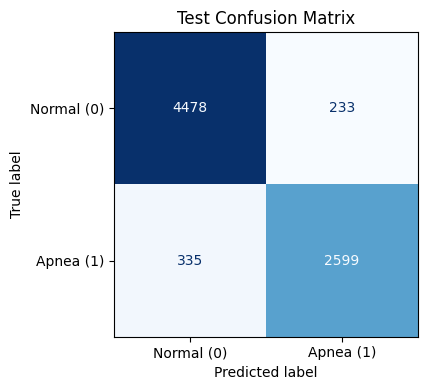

In [16]:
# Confusion matrix on test set
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()
y_true_cm = []
y_pred_cm = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)

        y_true_cm.extend(y_batch.cpu().numpy())
        y_pred_cm.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true_cm, y_pred_cm, labels=[0, 1])
print('Confusion Matrix (rows=true, cols=pred)')
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Apnea (1)'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Test Confusion Matrix')
plt.tight_layout()
plt.show()
